# DAY 153 - Multi-Task Learning (MTL): The Hydra Architecture
@A.IPYNB

### The Concept
Humans don't learn tasks in isolation. Learning to recognize a "red apple" teaches you about the shape "apple" and the color "red" at the same time.

MTL mimics this by training a single model on multiple related tasks.

### Why do it?
1.  **Efficiency:** One model does the work of two.
2.  **Regularization:** The model can't overfit to the noise of Task A because it also has to solve Task B. It is forced to learn robust, generalized features.

### The Architecture: Hard Parameter Sharing
This is the most common MTL setup.


-   **Shared Backbone (Encoder):** Extracts features (edges, textures). Shared by all tasks.
-   **Task-Specific Heads:** Specialized layers that take the shared features and make a specific prediction.

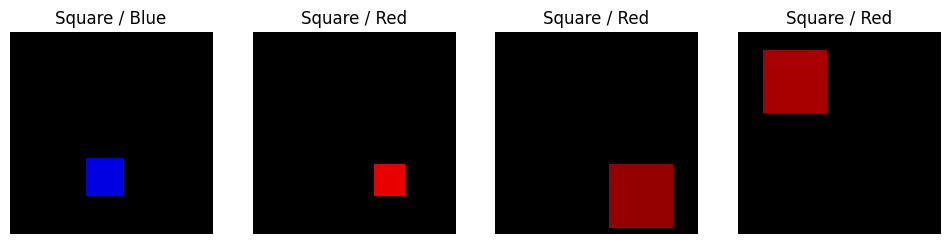

In [1]:
# @title 1. Create the "Shapes & Colors" Dataset
# We generate a synthetic dataset

# Input: 32x32 RGB Images
# Task 1: Shape (Square vs Circle)
# Task 2: Color (Red vs Blue)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Parameters
NUM_SAMPLES = 2000
IMG_SIZE = 32

class Syntheticdataset(Dataset):
    def __init__(self, n_samples):
        self.images = []
        self.shape_labels = [] # 0: Square, 1: Circle
        self.color_labels = [] # 0: Red, 1: Blue

        for _ in range(n_samples):
            img = np.zeros((3, IMG_SIZE, IMG_SIZE), dtype=np.float32)
            color = np.random.randint(0, 2) # 0=Red, 1=Blue
            channel = 0 if color == 0 else 2 # Set Red or Blue channel
            intensity = np.random.uniform(0.5, 1.0)

            shape = np.random.randint(0, 2) # 0=Square, 1=Circle
            size = np.random.randint(5, 12)
            x, y = np.random.randint(0, IMG_SIZE-size), np.random.randint(0, IMG_SIZE-size)

            if shape == 0: # Square
                img[channel, x:x+size, y:y+size] = intensity
            else:
                center_x, center_y = x+size//2, y+size//2
                radius = size//2
                Y, X = np.ogrid[:IMG_SIZE, :IMG_SIZE]
                mask = (X - center_x)**2 + (Y - center_y)**2 <= radius**2
                img[channel, mask] = intensity

            self.images.append(img)
            self.shape_labels.append(shape)
            self.color_labels.append(color)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return (torch.tensor(self.images[idx]),
                torch.tensor(self.shape_labels[idx]),
                torch.tensor(self.color_labels[idx]))

data = Syntheticdataset(NUM_SAMPLES)
loader = DataLoader(data, batch_size=32, shuffle=True)

images, s_labels, c_labels = next(iter(loader))
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    ax[i].imshow(images[i].permute(1, 2, 0)) # CHW -> HWC
    s_text = "Square" if s_labels[i]==0 else "Circle"
    c_text = "Red" if c_labels[i]==0 else "Blue"
    ax[i].set_title(f"{s_text} / {c_text}")
    ax[i].axis('off')
plt.show()

In [2]:
# @title 2. Define the Multi-Task Model

# Lets see how the network splits at the end.

class HydraNet(nn.Module):
    def __init__(self):
        super(HydraNet, self).__init__()

        # SHARED BACKBONE (The "Body")

        # Learns features relevant to BOTH tasks (e.g., edges, intensity)
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 16x16
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 8x8
            nn.Flatten()
        )

        # flattened size: 32 channels * 8 * 8 = 2048
        self.input_dim = 32 * 8 * 8

        # HEAD 1: SHAPE CLASSIFIER
        self.shape_head = nn.Sequential(
            nn.Linear(self.input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # Binary: Square or Circle
        )

        # HEAD 2: COLOR CLASSIFIER
        self.color_head = nn.Sequential(
            nn.Linear(self.input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # Binary: Red or Blue
        )

    def forward(self, x):
        # Pass through shared body
        features = self.backbone(x)

        # Split into two paths
        shape_pred = self.shape_head(features)
        color_pred = self.color_head(features)

        return shape_pred, color_pred

model = HydraNet()
print(model)

HydraNet(
  (backbone): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (shape_head): Sequential(
    (0): Linear(in_features=2048, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
  (color_head): Sequential(
    (0): Linear(in_features=2048, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)


### The Math of Multi-Task Loss
We calculate loss for Task A and Task B separately, then sum them up.

$$L_{total} = L_{shape} + \lambda \cdot L_{color}$$

*Note: $\lambda$ is a weight term. If one task is much harder than the other, we might give it more weight. Here we assume equal importance ($\lambda=1$).*

In [3]:
# @title 3. Define Loss & Optimizer

# We use CrossEntropy for both tasks since they are classification

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_batch(images, shape_targets, color_targets):
    optimizer.zero_grad()

    # Forward Pass (Get both predictions)
    shape_pred, color_pred = model(images)
    loss_shape = criterion(shape_pred, shape_targets)
    loss_color = criterion(color_pred, color_targets)

    # Combine Losses (The Hydra Equation)
    total_loss = loss_shape + loss_color
    total_loss.backward()
    optimizer.step()

    return total_loss.item(), loss_shape.item(), loss_color.item()

print("Loss function defined: L_total = L_shape + L_color")

Loss function defined: L_total = L_shape + L_color


In [4]:
# @title 4. Train the Hydra
epochs = 5

print("Starting Training...")
for epoch in range(epochs):
    epoch_loss = 0
    s_acc = 0
    c_acc = 0

    for images, s_labels, c_labels in loader:
        loss, ls, lc = train_batch(images, s_labels, c_labels)
        epoch_loss += loss

    print(f"Epoch {epoch+1}/{epochs} | Total Loss: {epoch_loss/len(loader):.4f}")

print("Training Complete.")

Starting Training...
Epoch 1/5 | Total Loss: 0.9493
Epoch 2/5 | Total Loss: 0.6888
Epoch 3/5 | Total Loss: 0.6746
Epoch 4/5 | Total Loss: 0.6545
Epoch 5/5 | Total Loss: 0.5669
Training Complete.


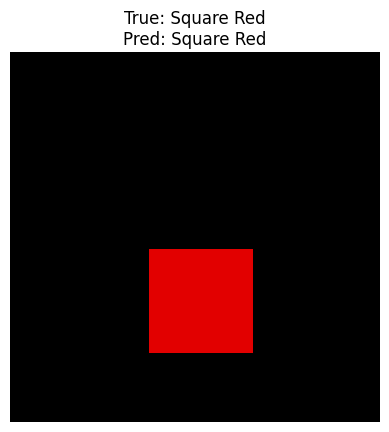

In [5]:
# @title 5. Test the Multi-Task Capabilities

# We will generate a NEW random sample and see if the model
# can answer two questions at once.


test_data = Syntheticdataset(1)
img, true_s, true_c = test_data[0]

img_batch = img.unsqueeze(0)

model.eval()
with torch.no_grad():
    p_s, p_c = model(img_batch)
    pred_s = torch.argmax(p_s, dim=1).item()
    pred_c = torch.argmax(p_c, dim=1).item()

shapes = {0: "Square", 1: "Circle"}
colors = {0: "Red", 1: "Blue"}
plt.imshow(img.permute(1, 2, 0))
plt.axis('off')
plt.title(f"True: {shapes[true_s.item()]} {colors[true_c.item()]}\nPred: {shapes[pred_s]} {colors[pred_c]}")
plt.show()

### Analysis of Results
As seen in the inference step, our **HydraNet** successfully predicted:
1.  **Shape:** Square
2.  **Color:** Red

It did this using a **single forward pass** through one shared backbone.

### The Strategic Win
In a traditional setup, you would need two separate models:
* Model A (Shape): ~2,000 parameters
* Model B (Color): ~2,000 parameters
* **Total:** ~4,000 parameters

With Multi-Task Learning (Hard Parameter Sharing):
* Shared Backbone: ~1,500 parameters
* Shape Head: ~500 parameters
* Color Head: ~500 parameters
* **Total:** ~2,500 parameters

**You achieved the same intelligence with ~40% fewer parameters.**

### Real-World Applications
This architecture is the standard for:
1.  **Self-Driving Cars:** One camera feed $\rightarrow$ Detect Pedestrians (Task A) + Detect Lane Lines (Task B) + Read Traffic Signs (Task C).
2.  **Recommendation Systems:** One user history $\rightarrow$ Predict "Click Probability" (Task A) + Predict "Watch Time" (Task B).
3.  **NLP (BERT):** The pre-training of BERT itself is multi-task learning (Masked Language Modeling + Next Sentence Prediction).
